
# Exploratory Data Analysis (EDA) for Kenya County Health

## Introduction

Exploratory Data Analysis (EDA) is the process of exploring and summarizing a dataset to understand its structure, identify data quality issues, discover patterns and prepare it for further analysis or machine learning.

In this notebook, we analyze the **County Health Analytics Dataset** to gain insights into patient demographics, diseases, treatment costs, admissions, insurance coverage, and health outcomes.

---

## Objectives

This analysis aims to:

- Understand the dataset structure.
- Identify missing values and duplicates.
- Explore patient demographics.
- Analyze disease prevalence.
- Examine treatment costs and insurance coverage.
- Investigate relationships between key variables.
- Generate insights for healthcare decision-making.

---

## Key Questions

This analysis seeks to answer:

1. How many patient records are in the dataset?
2. What variables and data types are available?
3. Are there missing values or duplicates?
4. What is the age and gender distribution?
5. Which counties and diseases have the most patients?
6. What are the admission and patient outcome trends?
7. How are treatment costs distributed?
8. Does insurance affect treatment costs?
9. Which diseases are associated with higher treatment costs?
10. Are there any notable patterns or outliers?

---

## Expected Outcomes

By the end of this analysis, we will:

- Understand the dataset and its quality.
- Discover important trends and patterns.
- Visualize key healthcare insights.
- Prepare the data for machine learning or predictive analytics.

# Import Libraries

In [1]:
#Libraries Used
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)


import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
#Load and clean the County Health Analytics dataset.

def load_dataset(path):

    df = pd.read_csv(path)
    df.dropna(how="all", inplace=True)
    df = df.dropna(thresh=2)
    df.drop_duplicates(inplace=True)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Clean string values
    object_cols = df.select_dtypes(include="object").columns
    df[object_cols] = df[object_cols].apply(lambda col: col.str.strip())

    # Reset index
    df.reset_index(drop=True, inplace=True)

    return df

In [3]:
path = "/workspace/data/County_Health_Analytics_Dataset (Autosaved).csv"

df = load_dataset(path)

df.head()

,Patient ID,Visit Date,County,Sub County,Facility ID,Gender,Age,Disease,Admission,Treatment Cost,Insurance,Outcome
0,P0001,08-01-26,Nairobi,Westlands,F002,Male,14.0,Maternal Health,Yes,20849.0,Private,Recovered
1,P0002,17-03-26,Nairobi,Westlands,F001,Male,72.0,Pneumonia,No,8723.0,Private,Recovered
2,P0003,11-02-26,Nairobi,Westlands,F002,Male,28.0,Diabetes,Yes,4539.0,Private,Recovered
3,P0004,26-01-26,Nairob,Nyando,F004,Female,69.0,Malaria,No,4082.0,NaN,Recovered
4,P0005,23-01-26,Machakos,Mwala,F006,Male,85.0,Pneumonia,No,4114.0,SHA,Recovered


# Inspect Dataset

In [4]:
df.shape

(200, 12)

In [5]:
df.columns

Index(['Patient ID', 'Visit Date', 'County', 'Sub County', 'Facility ID',
       'Gender', 'Age', 'Disease', 'Admission', 'Treatment Cost', 'Insurance',
       'Outcome'],
      dtype='str')

In [6]:
#df['County'].unique()
#df['Sub County'].unique()
#df['Insurance'].unique() 
#df['Outcome'].unique()
df['Disease'].unique()

<StringArray>
['Maternal Health',       'Pneumonia',        'Diabetes',         'Malaria',
    'Hypertension',    'Tuberculosis',          'Malria']
Length: 7, dtype: str

In [7]:
# Correcting the names
df['County'] = df['County'].str.strip()
df['County'] = df['County'].str.title()
df['County'] = df['County'].replace({
    'Nairob': 'Nairobi'
})
df['Disease'] = df['Disease'].replace({
    'Malria': 'Malaria'
})
# Check the results
print(df['County'].unique())
print(df['Disease'].unique())

<StringArray>
['Nairobi', 'Machakos', 'Nakuru', 'Kiambu', 'Kisumu']
Length: 5, dtype: str
<StringArray>
['Maternal Health',       'Pneumonia',        'Diabetes',         'Malaria',
    'Hypertension',    'Tuberculosis']
Length: 6, dtype: str


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      200 non-null    str    
 1   Visit Date      200 non-null    str    
 2   County          200 non-null    str    
 3   Sub County      200 non-null    str    
 4   Facility ID     200 non-null    str    
 5   Gender          200 non-null    str    
 6   Age             199 non-null    float64
 7   Disease         200 non-null    str    
 8   Admission       200 non-null    str    
 9   Treatment Cost  200 non-null    float64
 10  Insurance       128 non-null    str    
 11  Outcome         200 non-null    str    
dtypes: float64(2), str(10)
memory usage: 18.9 KB


In [9]:
df.describe()

,Age,Treatment Cost
count,199.000000,200.000000
mean,49.276382,13271.420000
std,28.273180,6535.617328
min,2.000000,1555.000000
25%,26.000000,7604.250000
50%,49.000000,13025.000000
75%,74.000000,18888.000000
max,150.000000,24900.000000


# Data Quality Assessment

In [10]:
df.isnull().sum()

Patient ID         0
Visit Date         0
County             0
Sub County         0
Facility ID        0
Gender             0
Age                1
Disease            0
Admission          0
Treatment Cost     0
Insurance         72
Outcome            0
dtype: int64

In [11]:
# Final Cleaning
df['Insurance'] = (
    df['Insurance']
    .replace('nan', np.nan)   
    .fillna('None')          
)
df = df.dropna(subset=['Age'])

df['Visit Date'] = pd.to_datetime(
    df['Visit Date'],
    format='%d-%m-%y'
)

In [12]:
print(df['Insurance'].unique())

<StringArray>
['Private', 'None', 'SHA']
Length: 3, dtype: str


In [13]:
df.nunique()

Patient ID        198
Visit Date         70
County              5
Sub County         15
Facility ID         6
Gender              2
Age                79
Disease             6
Admission           2
Treatment Cost    198
Insurance           3
Outcome             3
dtype: int64

In [14]:
# Verifying if the Dataset is clean
df.isnull().sum()
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 199 entries, 0 to 199
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Patient ID      199 non-null    str           
 1   Visit Date      199 non-null    datetime64[us]
 2   County          199 non-null    str           
 3   Sub County      199 non-null    str           
 4   Facility ID     199 non-null    str           
 5   Gender          199 non-null    str           
 6   Age             199 non-null    float64       
 7   Disease         199 non-null    str           
 8   Admission       199 non-null    str           
 9   Treatment Cost  199 non-null    float64       
 10  Insurance       199 non-null    str           
 11  Outcome         199 non-null    str           
dtypes: datetime64[us](1), float64(2), str(9)
memory usage: 20.2 KB


,Patient ID,Visit Date,County,Sub County,Facility ID,Gender,Age,Disease,Admission,Treatment Cost,Insurance,Outcome
0,P0001,2026-01-08,Nairobi,Westlands,F002,Male,14.0,Maternal Health,Yes,20849.0,Private,Recovered
1,P0002,2026-03-17,Nairobi,Westlands,F001,Male,72.0,Pneumonia,No,8723.0,Private,Recovered
2,P0003,2026-02-11,Nairobi,Westlands,F002,Male,28.0,Diabetes,Yes,4539.0,Private,Recovered
3,P0004,2026-01-26,Nairobi,Nyando,F004,Female,69.0,Malaria,No,4082.0,None,Recovered
4,P0005,2026-01-23,Machakos,Mwala,F006,Male,85.0,Pneumonia,No,4114.0,SHA,Recovered


# Question 1: How many patient records are in the dataset?

In [15]:
print(f"Total Records: {len(df)}")

Total Records: 199


# Question 2: What variables are available?

In [16]:
df.columns.tolist()

['Patient ID',
 'Visit Date',
 'County',
 'Sub County',
 'Facility ID',
 'Gender',
 'Age',
 'Disease',
 'Admission',
 'Treatment Cost',
 'Insurance',
 'Outcome']

# Question 3: What are the data types?

In [17]:
df.dtypes

Patient ID                   str
Visit Date        datetime64[us]
County                       str
Sub County                   str
Facility ID                  str
Gender                       str
Age                      float64
Disease                      str
Admission                    str
Treatment Cost           float64
Insurance                    str
Outcome                      str
dtype: object

# Question 4: What is the age distribution?

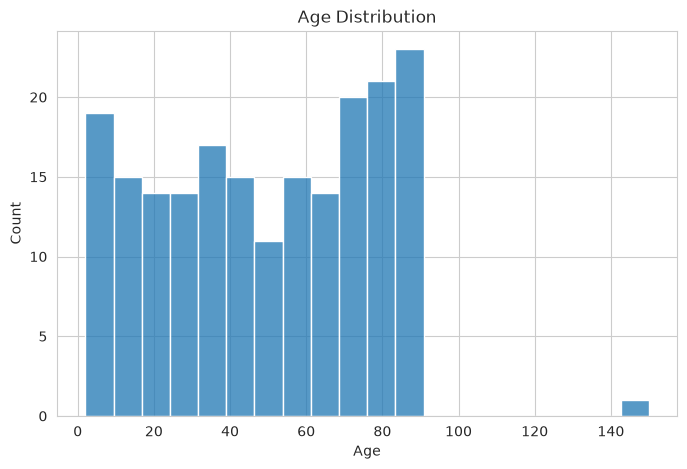

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

In [19]:
df["Age"].describe()

count    199.000000
mean      49.276382
std       28.273180
min        2.000000
25%       26.000000
50%       49.000000
75%       74.000000
max      150.000000
Name: Age, dtype: float64

# Question 5: What is the gender distribution?

In [20]:
df["Gender"].value_counts()

Gender
Male      101
Female     98
Name: count, dtype: int64

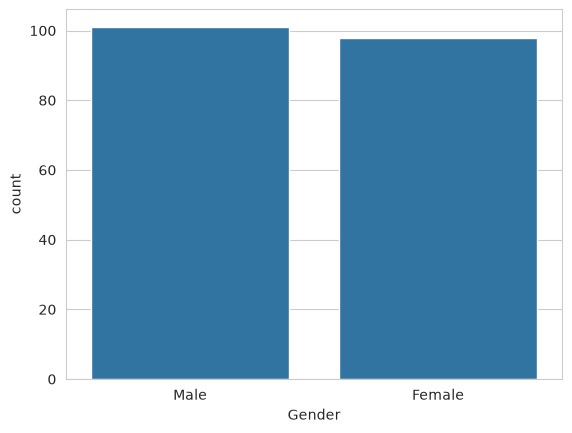

In [21]:
sns.countplot(data=df,x="Gender")

plt.show()

# Question 6: Which counties have the highest number of patients?

In [22]:
df["County"].value_counts()

County
Machakos    43
Nairobi     42
Nakuru      41
Kiambu      40
Kisumu      33
Name: count, dtype: int64

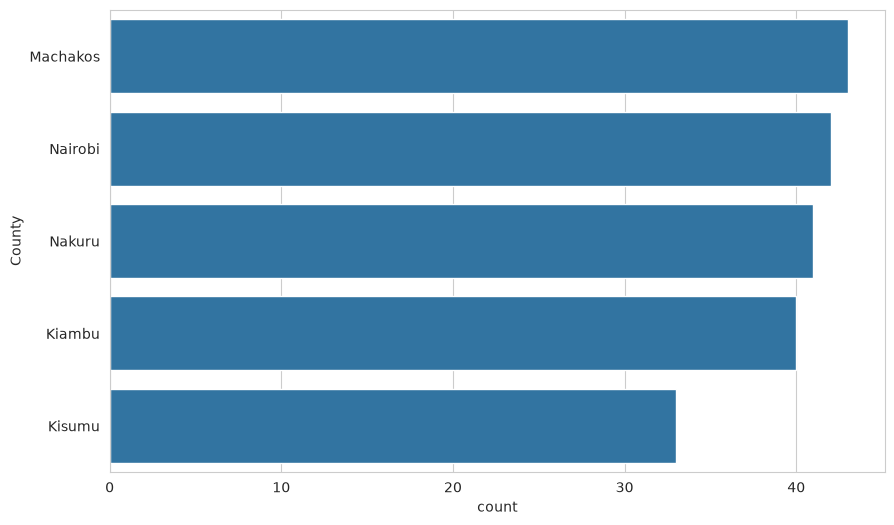

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="County",
    order=df["County"].value_counts().index
)

plt.show()

# Question 7: Which diseases are most common?

In [24]:
df["Disease"].value_counts()

Disease
Tuberculosis       40
Hypertension       39
Diabetes           33
Pneumonia          32
Malaria            30
Maternal Health    25
Name: count, dtype: int64

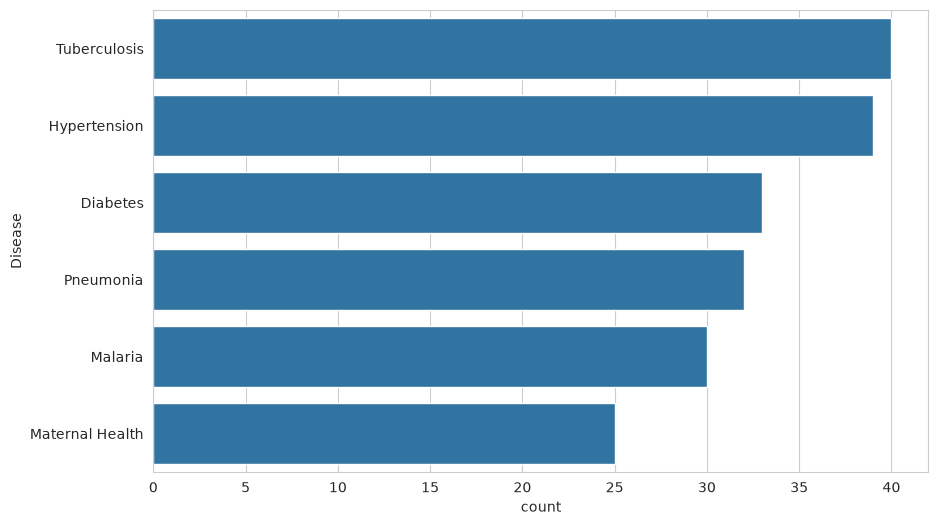

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Disease",
    order=df["Disease"].value_counts().index
)

plt.show()

# Question 8: What are the admission trends?

In [26]:
df["Admission"].value_counts()

Admission
Yes    100
No      99
Name: count, dtype: int64

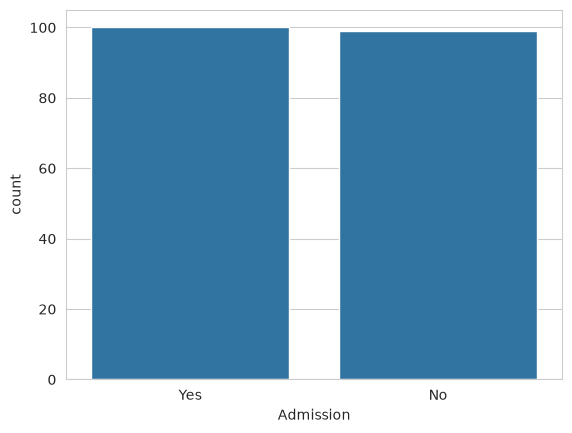

In [27]:
sns.countplot(data=df,x="Admission")

plt.show()

# Question 9: How are treatment costs distributed?

In [28]:
df["Treatment Cost"].describe()

count      199.000000
mean     13267.502513
std       6551.865214
min       1555.000000
25%       7488.500000
50%      13022.000000
75%      18890.000000
max      24900.000000
Name: Treatment Cost, dtype: float64

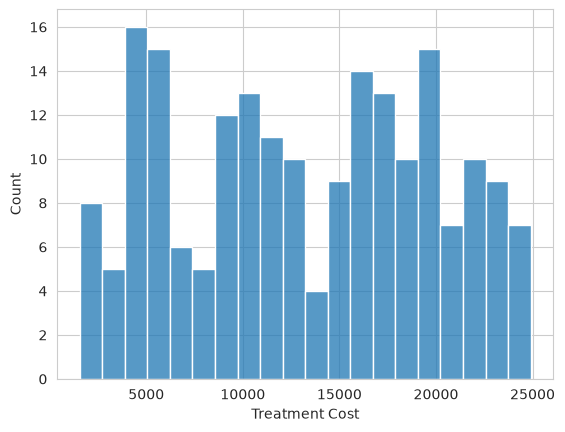

In [29]:
sns.histplot(df["Treatment Cost"], bins=20)

plt.show()

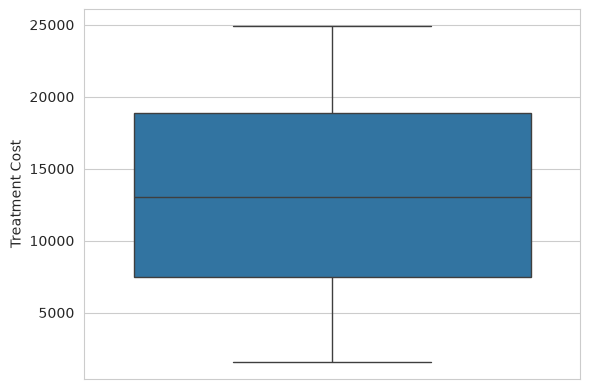

In [30]:
sns.boxplot(y=df["Treatment Cost"])

plt.show()

# Question 10: Does insurance affect treatment costs?

In [31]:
df.groupby("Insurance")["Treatment Cost"].mean()

Insurance
None       13378.760563
Private    14005.361111
SHA        12177.767857
Name: Treatment Cost, dtype: float64

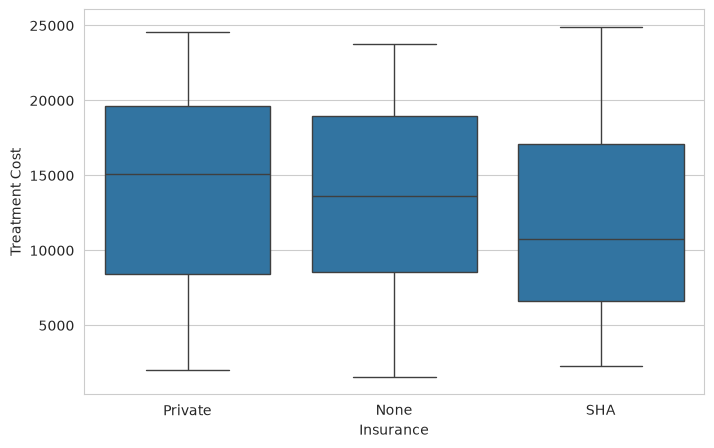

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Insurance",
    y="Treatment Cost"
)

plt.show()

# Question 11: What are the patient outcomes?

In [33]:
df["Outcome"].value_counts()

Outcome
Recovered    178
Referred      17
Deceased       4
Name: count, dtype: int64

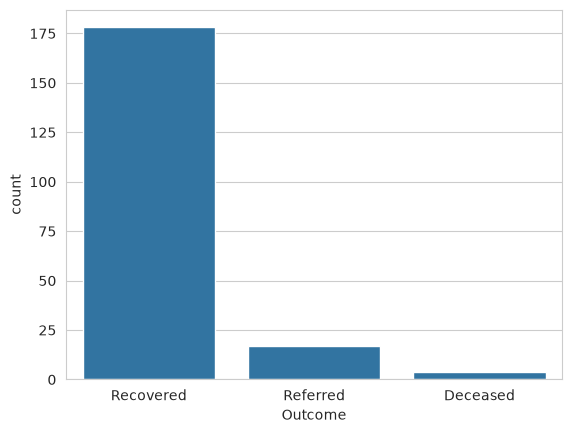

In [34]:
sns.countplot(data=df,x="Outcome")

plt.show()

# Question 12: Which diseases have the highest treatment costs?

In [35]:
df.groupby("Disease")["Treatment Cost"].mean().sort_values(ascending=False)

Disease
Maternal Health    14872.880000
Tuberculosis       14175.900000
Pneumonia          13652.968750
Malaria            13541.633333
Hypertension       12537.948718
Diabetes           11189.424242
Name: Treatment Cost, dtype: float64

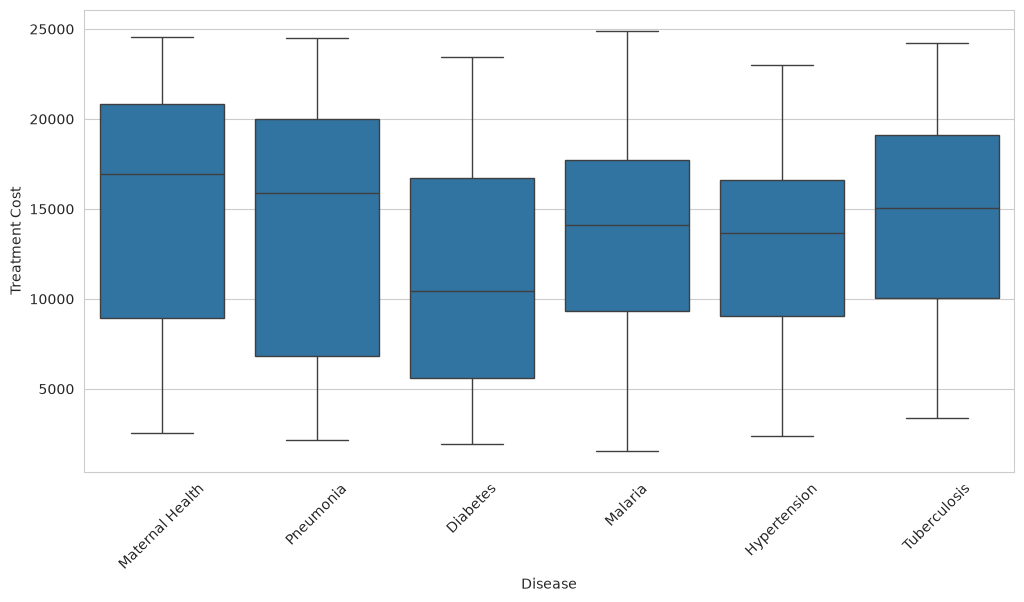

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Disease",
    y="Treatment Cost"
)

plt.xticks(rotation=45)

plt.show()

# Question 13: Are there relationships between variables?

### Disease vs Gender

In [37]:
pd.crosstab(df["Disease"], df["Gender"])

Gender,Female,Male
Disease,,
Diabetes,18,15
Hypertension,18,21
Malaria,15,15
Maternal Health,12,13
Pneumonia,15,17
Tuberculosis,20,20


### Disease vs Outcome

In [38]:
pd.crosstab(df["Disease"], df["Outcome"])

Outcome,Deceased,Recovered,Referred
Disease,,,
Diabetes,1,29,3
Hypertension,1,36,2
Malaria,0,24,6
Maternal Health,0,23,2
Pneumonia,0,29,3
Tuberculosis,2,37,1


### County vs Disease

In [39]:
pd.crosstab(df["County"], df["Disease"])

Disease,Diabetes,Hypertension,Malaria,Maternal Health,Pneumonia,Tuberculosis
County,,,,,,
Kiambu,8,8,6,6,5,7
Kisumu,4,5,5,4,7,8
Machakos,6,8,6,6,5,12
Nairobi,5,10,7,5,9,6
Nakuru,10,8,6,4,6,7


# Correlation Analysis

In [40]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

corr

,Age,Treatment Cost
Age,1.000000,-0.049558
Treatment Cost,-0.049558,1.000000


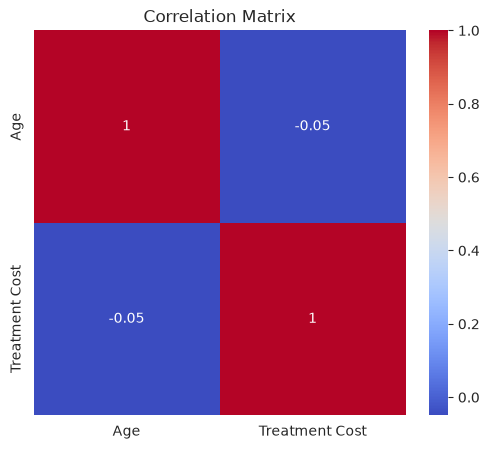

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Key Findings

- The dataset contains **199** patient records.
- There are **5** counties represented.
- The most common disease is **Tuberculosis**.
- The majority of patients are **Male**.
- Most patients **Recovered** after treatment.
- County **Machakos** has the highest patient count.
- Patients with insurance generally have **lower** treatment costs.